# Feature Engineering of Market Risk Variables

This notebook is the second step of the empirical pipeline developed for the TFM.

Its objective is to construct a set of market-based financial features from the IBEX 35 dataset generated in Notebook 1. These variables are designed to characterize the behaviour of the market in terms of performance, volatility, downside risk, extreme risk, cumulative deterioration and distributional shape.

The notebook performs six main tasks:

1. Load the cleaned dataset generated in Notebook 1
2. Construct rolling performance and risk features
3. Assemble the master dataset for Chapter 2
4. Define the train/test split schemes
5. Produce descriptive tables and figures for Chapter 2
6. Export datasets, tables and figures for later analysis

The final outputs of this notebook are:

- `data/processed/dataset_cap2_master.csv`
- `data/processed/dataset_cap3_input.csv`
- `tables/dataset_summary.csv`
- `tables/descriptive_statistics.csv`
- `tables/correlation_matrix.csv`
- `figures/chapter2/*`

## Notebook overview

This notebook takes as input the file generated in Notebook 1:

`data/raw/ibex_prices.csv`

and transforms it into the empirical dataset used in Chapter 2 of the TFM.

The resulting variables are intended to capture:

- market return dynamics
- volatility
- downside risk
- tail risk
- cumulative market deterioration
- distributional asymmetry

## 1. Environment setup

We begin by importing the required libraries and defining the technical and methodological parameters of the notebook.

All paths are defined using relative references in order to keep the pipeline reproducible and portable across machines.

In [107]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.6f}".format)

# Matplotlib config (consistente para figuras del TFM)
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

## 2. Project paths

The notebook uses relative paths anchored at the repository root.

The raw dataset generated in Notebook 1 is loaded from `data/raw/`, while the outputs of this notebook are exported to `data/processed/`, `tables/` and `figures/chapter2/`.

In [108]:
if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "tables"
FIGURES_DIR = PROJECT_ROOT / "figures" / "chapter2"

# Create directories if they don't exist
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Check raw data exists (importante para reproducibilidad)
raw_file = RAW_DATA_DIR / "ibex_prices.csv"
if not raw_file.exists():
    raise FileNotFoundError(f"Missing input file: {raw_file}")

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DATA_DIR)
print("Processed data directory:", PROCESSED_DATA_DIR)
print("Tables directory:", TABLES_DIR)
print("Figures directory:", FIGURES_DIR)

Project root: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio
Raw data directory: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/data/raw
Processed data directory: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/data/processed
Tables directory: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables
Figures directory: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/figures/chapter2


## 3. Methodological parameters

This section centralizes the empirical choices used throughout the notebook.

The feature set is intentionally compact and organized around two rolling horizons:

- 20 trading days, representing short-term market dynamics
- 60 trading days, representing medium-term market dynamics

Extreme risk is estimated using historical VaR and CVaR at the 95% confidence level over a 60-day rolling window.

In [109]:
INPUT_FILE = RAW_DATA_DIR / "ibex_prices.csv"

# Rolling windows
SHORT_WINDOW = 20
MEDIUM_WINDOW = 60

# Tail risk parameters
VAR_CONFIDENCE = 0.95
VAR_TAIL_PROB = 1 - VAR_CONFIDENCE

# Sample splits (aligned with Chapter 2)
MAIN_TEST_START = pd.Timestamp("2021-01-01")
ROBUST_TEST_START = pd.Timestamp("2020-01-01")

## 4. Load base dataset

We now load the cleaned dataset generated in Notebook 1, the starting point of the feature engineering process.

In [110]:
## 4. Load base dataset

# Load dataset
df = pd.read_csv(INPUT_FILE, parse_dates=["date"])

# Basic validation
required_cols = ["date", "ibex_close", "ret_1d"]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Sort and set time index (clave para rolling)
df = df.sort_values("date").reset_index(drop=True)
df = df.set_index("date")

print("Dataset loaded correctly")
print(df.shape)
df.head()

Dataset loaded correctly
(6690, 2)


,ibex_close,ret_1d
date,,
2000-01-04,"11,206.587891",-0.035364
2000-01-05,"10,863.088867",-0.031131
2000-01-07,"11,102.388672",0.021790
2000-01-10,"11,173.288086",0.006366
2000-01-11,"11,012.389648",-0.014505


## 5. Initial validation of the base dataset

Before constructing additional variables, we verify that the input dataset has the expected structure and no contains data integrity issues.

In [111]:
## 5. Initial validation of the base dataset

print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("Date range:", df.index.min(), "to", df.index.max())
print("Missing values:\n", df.isna().sum())
print("Duplicate dates:", df.index.duplicated().sum())
print("Chronologically sorted:", df.index.is_monotonic_increasing)

# Assertions
assert df.index.is_monotonic_increasing, "Dates are not ordered"
assert df.index.duplicated().sum() == 0, "Duplicate dates found"

Shape: (6690, 2)
Columns: ['ibex_close', 'ret_1d']
Date range: 2000-01-04 00:00:00 to 2026-04-23 00:00:00
Missing values:
 ibex_close    0
ret_1d        0
dtype: int64
Duplicate dates: 0
Chronologically sorted: True


## 6. Construction of market features

The feature set is organized into six conceptual blocks:

1. performance features
2. volatility features
3. downside risk features
4. tail risk features
5. cumulative deterioration
6. distributional shape

These features are intended to characterize the state of the market at each point in time using only information available up to that date. Together, they provide the empirical basis for the descriptive analysis developed in Chapter 2.

### 6.1 Performance features

For log returns, the correct cumulative return over a rolling window is the sum of the log returns in that window. This follows from the additive property of log returns over time.

Therefore:

- `ret_20d` is computed as the rolling sum of daily log returns over 20 trading days
- `ret_60d` is computed as the rolling sum of daily log returns over 60 trading days

In [112]:
df["ret_20d"] = df["ret_1d"].rolling(window=SHORT_WINDOW, min_periods=SHORT_WINDOW).sum()
df["ret_60d"] = df["ret_1d"].rolling(window=MEDIUM_WINDOW, min_periods=MEDIUM_WINDOW).sum()

### 6.2 Volatility features

Volatility is computed over 20 and 60 trading days in order to capture both short-term and medium-term fluctuations in market risk.

In [113]:
df["vol_20d"] = df["ret_1d"].rolling(window=SHORT_WINDOW, min_periods=SHORT_WINDOW).std(ddof=1)
df["vol_60d"] = df["ret_1d"].rolling(window=MEDIUM_WINDOW, min_periods=MEDIUM_WINDOW).std(ddof=1)

### 6.2.1 EWMA 

In [114]:
EWMA_LAMBDA = 0.94

df["ewma_vol"] = np.sqrt(
    df["ret_1d"].pow(2).ewm(alpha=1 - EWMA_LAMBDA, adjust=False).mean()
)

### 6.3 Downside risk features

Downside risk aims to isolate the variability associated with negative returns only.

In [115]:
def downside_volatility(series):
    negative_returns = series[series < 0]
    if len(negative_returns) == 0:
        return np.nan
    return negative_returns.std(ddof=1)

df["downside_vol_20d"] = df["ret_1d"].rolling(window=SHORT_WINDOW).apply(
    downside_volatility, raw=False
)

df["downside_vol_60d"] = df["ret_1d"].rolling(window=MEDIUM_WINDOW).apply(
    downside_volatility, raw=False
)

### 6.4 Tail risk features

Extreme market risk is captured using historical (non-parametric) Value at Risk (VaR) and Conditional Value at Risk (CVaR) at the 95% confidence level over a 60-day rolling window.

In [116]:
def historical_var(series, alpha=VAR_TAIL_PROB):
    return np.quantile(series, alpha)

def historical_cvar(series, alpha=VAR_TAIL_PROB):
    var_threshold = np.quantile(series, alpha)
    tail_losses = series[series <= var_threshold]
    return tail_losses.mean() if len(tail_losses) > 0 else np.nan

df["var_95_60d"] = df["ret_1d"].rolling(window=MEDIUM_WINDOW, min_periods=MEDIUM_WINDOW).apply(
    lambda x: historical_var(x), raw=True
)

df["cvar_95_60d"] = df["ret_1d"].rolling(window=MEDIUM_WINDOW, min_periods=MEDIUM_WINDOW).apply(
    lambda x: historical_cvar(x), raw=True
)

### 6.5 Drawdown and cumulative market deterioration

Drawdown measures the percentage decline of the index relative to its running historical maximum.

In [117]:
running_max = df["ibex_close"].cummax()
df["drawdown"] = df["ibex_close"] / running_max - 1.0

### 6.6 Distributional shape

As a complementary feature, we compute rolling skewness over 60 trading days.

In [118]:
df["skew_60d"] = df["ret_1d"].rolling(
    window=MEDIUM_WINDOW,
    min_periods=MEDIUM_WINDOW
).skew()

## 7. Master dataset assembly

Once all features have been constructed, they are assembled into a single master dataset.

The initial rows affected by rolling window computations are removed so that the final dataset only contains observations with fully available information across all variables.

In [119]:
feature_columns = [
    "ibex_close",
    "ret_1d",
    "ret_20d",
    "ret_60d",
    "vol_20d",
    "vol_60d",
    "ewma_vol", 
    "downside_vol_20d",
    "downside_vol_60d",
    "var_95_60d",
    "cvar_95_60d",
    "drawdown",
    "skew_60d",
]

master_df = df[feature_columns].copy()
master_df = master_df.dropna(subset=feature_columns)
master_df = master_df.reset_index()   # recupera date como columna
master_df = master_df.sort_values("date").reset_index(drop=True)

## 8. Validation of the master dataset

Before moving to the sample split and descriptive analysis, we verify that the feature engineering process has produced a clean and internally consistent dataset.

In [120]:
print("Master dataset shape:", master_df.shape)
print("Date range:", master_df["date"].min(), "to", master_df["date"].max())
print("Missing values:\n", master_df.isna().sum())
print("Columns:", list(master_df.columns))
print(master_df.dtypes)

Master dataset shape: (6631, 14)
Date range: 2000-03-28 00:00:00 to 2026-04-23 00:00:00
Missing values:
 date                0
ibex_close          0
ret_1d              0
ret_20d             0
ret_60d             0
vol_20d             0
vol_60d             0
ewma_vol            0
downside_vol_20d    0
downside_vol_60d    0
var_95_60d          0
cvar_95_60d         0
drawdown            0
skew_60d            0
dtype: int64
Columns: ['date', 'ibex_close', 'ret_1d', 'ret_20d', 'ret_60d', 'vol_20d', 'vol_60d', 'ewma_vol', 'downside_vol_20d', 'downside_vol_60d', 'var_95_60d', 'cvar_95_60d', 'drawdown', 'skew_60d']
date                datetime64[us]
ibex_close                 float64
ret_1d                     float64
ret_20d                    float64
ret_60d                    float64
vol_20d                    float64
vol_60d                    float64
ewma_vol                   float64
downside_vol_20d           float64
downside_vol_60d           float64
var_95_60d                 float6

In [121]:
assert master_df["date"].is_monotonic_increasing, "Dates are not ordered"

assert (master_df["downside_vol_20d"] >= 0).all(), "Negative downside_vol_20d found"
assert (master_df["downside_vol_60d"] >= 0).all(), "Negative downside_vol_60d found"

assert (master_df["drawdown"] <= 0).all(), "Positive drawdown found"

cvar_check = (master_df["cvar_95_60d"] <= master_df["var_95_60d"] + 1e-10).all()
print("CVaR more severe than VaR:", cvar_check)

assert cvar_check, "CVaR should be more severe than VaR"

CVaR more severe than VaR: True


## 9. Definition of sample splits

The final dataset is tagged using two chronological split schemes:

- main split: training period 2002–2020, test period 2021–present (out-of-sample evaluation)
- robustness split: training period 2002–2019, test period 2020–present (COVID-19 stress period)

In [122]:
master_df["sample_split_main"] = np.where(
    master_df["date"] < MAIN_TEST_START, "train", "test"
)

master_df["sample_split_main"] = master_df["sample_split_main"].astype("category")


master_df["sample_split_robust"] = np.where(
    master_df["date"] < ROBUST_TEST_START, "train", "test"
)

master_df["sample_split_robust"] = master_df["sample_split_robust"].astype("category")

## 10. Validation of the temporal split

We verify that both split schemes produce the expected chronological segmentation of the sample.

In [123]:
print("Main split counts:")
print(master_df["sample_split_main"].value_counts().sort_index())
print()

print("Robust split counts:")
print(master_df["sample_split_robust"].value_counts().sort_index())
print()

print("Main split date ranges:")
print(master_df.groupby("sample_split_main", observed=True)["date"].agg(["min", "max"]))
print()

print("Robust split date ranges:")
print(master_df.groupby("sample_split_robust", observed=True)["date"].agg(["min", "max"]))

Main split counts:
sample_split_main
test     1357
train    5274
Name: count, dtype: int64

Robust split counts:
sample_split_robust
test     1614
train    5017
Name: count, dtype: int64

Main split date ranges:
                         min        max
sample_split_main                      
test              2021-01-04 2026-04-23
train             2000-03-28 2020-12-31

Robust split date ranges:
                           min        max
sample_split_robust                      
test                2020-01-02 2026-04-23
train               2000-03-28 2019-12-31


## 11. Descriptive analysis of the dataset

This section provides a descriptive characterization of the final market-state dataset obtained after the feature engineering process.

### 11.1 Structural summary

We first summarize the effective sample coverage, dataset size and sample split composition after removing observations affected by rolling window computations.

In [124]:
dataset_summary = pd.DataFrame({
    "metric": [
        "effective_start_date",
        "effective_end_date",
        "total_observations",
        "main_train_observations",
        "main_test_observations",
        "robust_train_observations",
        "robust_test_observations",
        "number_of_features"
    ],
    "value": [
        str(master_df["date"].min().date()),
        str(master_df["date"].max().date()),
        len(master_df),
        (master_df["sample_split_main"] == "train").sum(),
        (master_df["sample_split_main"] == "test").sum(),
        (master_df["sample_split_robust"] == "train").sum(),
        (master_df["sample_split_robust"] == "test").sum(),
        master_df.shape[1] - 3
    ]
})

### 11.2 Descriptive statistics

We compute standard descriptive statistics for the main financial variables in the dataset.

In [125]:
analysis_columns = [
    "ret_1d",
    "ret_20d",
    "ret_60d",
    "vol_20d",
    "vol_60d",
    "downside_vol_20d",
    "downside_vol_60d",
    "var_95_60d",
    "cvar_95_60d",
    "drawdown",
    "skew_60d",
]

desc_stats = master_df[analysis_columns].agg([
    "mean",
    "median",
    "std",
    "min",
    lambda x: x.quantile(0.05),
    lambda x: x.quantile(0.95),
    "max",
    "skew",
    "kurt"
]).T

desc_stats.columns = [
    "mean",
    "median",
    "std",
    "min",
    "p5",
    "p95",
    "max",
    "skewness",
    "kurtosis"
]

desc_stats = desc_stats.round(6)

display(desc_stats)

# Export descriptive statistics table for inclusion in Chapter 2 (LaTeX)
desc_stats.to_latex(
    TABLES_DIR / "descriptive_statistics.tex",
    float_format="%.6f"
)

,mean,median,std,min,p5,p95,max,skewness,kurtosis
ret_1d,0.000058,0.000663,0.013997,-0.151512,-0.022313,0.020389,0.134836,-0.321314,8.237594
ret_20d,0.001073,0.006207,0.058653,-0.495334,-0.095617,0.083883,0.238578,-1.079110,5.741877
ret_60d,0.003642,0.012180,0.097313,-0.454563,-0.185099,0.142490,0.327023,-0.851529,1.659575
vol_20d,0.012374,0.010555,0.006625,0.003633,0.005682,0.024362,0.054200,2.173989,7.321425
vol_60d,0.012724,0.011275,0.005867,0.005026,0.006612,0.023845,0.041061,1.615566,3.346121
downside_vol_20d,0.007589,0.006608,0.004850,0.000315,0.002502,0.015897,0.049312,2.911132,15.410967
downside_vol_60d,0.008358,0.007261,0.004362,0.002440,0.003959,0.015890,0.031945,2.277252,7.490630
var_95_60d,-0.019625,-0.017098,0.009201,-0.062672,-0.036495,-0.008992,-0.004404,-1.396652,2.690040
cvar_95_60d,-0.027435,-0.023451,0.014419,-0.105520,-0.050900,-0.012731,-0.008387,-2.186995,7.436992
drawdown,-0.346177,-0.374327,0.143899,-0.626464,-0.531537,-0.036145,0.000000,0.820883,-0.028374


### 11.3 Preliminary financial interpretation

At a descriptive level, the dataset allows us to assess whether the market exhibits evidence of:

- non-normal return dynamics
- asymmetry in market risk
- heavy tails
- heterogeneity in the evolution of market stress over time

In [126]:
analysis_columns = [
    "ret_1d",
    "ret_20d",
    "ret_60d",
    "vol_20d",
    "vol_60d",
    "downside_vol_20d",
    "downside_vol_60d",
    "var_95_60d",
    "cvar_95_60d",
    "drawdown",
    "skew_60d",
]

desc_stats = master_df[analysis_columns].describe(percentiles=[0.05, 0.95]).T

desc_stats["median"] = master_df[analysis_columns].median()
desc_stats["skewness"] = master_df[analysis_columns].skew()
desc_stats["kurtosis"] = master_df[analysis_columns].kurtosis()

desc_stats = desc_stats[
    ["mean", "median", "std", "min", "5%", "95%", "max", "skewness", "kurtosis"]
]

desc_stats = desc_stats.rename(
    index={
        "ret_1d": "Return (1d)",
        "ret_20d": "Return (20d)",
        "ret_60d": "Return (60d)",
        "vol_20d": "Volatility (20d)",
        "vol_60d": "Volatility (60d)",
        "downside_vol_20d": "Downside vol. (20d)",
        "downside_vol_60d": "Downside vol. (60d)",
        "var_95_60d": "VaR 95% (60d)",
        "cvar_95_60d": "CVaR 95% (60d)",
        "drawdown": "Drawdown",
        "skew_60d": "Skewness (60d)",
    },
    columns={
        "mean": "Mean",
        "median": "Median",
        "std": "Std. Dev.",
        "min": "Min",
        "5%": "5\\%",
        "95%": "95\\%",
        "max": "Max",
        "skewness": "Skewness",
        "kurtosis": "Kurtosis",
    }
)

desc_stats = desc_stats.round(4)

display(desc_stats)

desc_stats.to_csv(TABLES_DIR / "descriptive_statistics.csv")

latex_table = desc_stats.to_latex(
    float_format="%.4f",
    escape=False,
    caption="Descriptive statistics of the main return and risk variables.",
    label="tab:descriptive_statistics",
    position="H"
)

# Ajuste clave para que no se corte la tabla
latex_table = latex_table.replace(
    "\\begin{tabular}",
    "\\resizebox{\\textwidth}{!}{%\n\\begin{tabular}"
).replace(
    "\\end{tabular}",
    "\\end{tabular}%\n}"
)

with open(TABLES_DIR / "descriptive_statistics.tex", "w", encoding="utf-8") as f:
    f.write(latex_table)

,Mean,Median,Std. Dev.,Min,5\%,95\%,Max,Skewness,Kurtosis
Return (1d),0.000100,0.000700,0.014000,-0.151500,-0.022300,0.020400,0.134800,-0.321300,8.237600
Return (20d),0.001100,0.006200,0.058700,-0.495300,-0.095600,0.083900,0.238600,-1.079100,5.741900
Return (60d),0.003600,0.012200,0.097300,-0.454600,-0.185100,0.142500,0.327000,-0.851500,1.659600
Volatility (20d),0.012400,0.010600,0.006600,0.003600,0.005700,0.024400,0.054200,2.174000,7.321400
Volatility (60d),0.012700,0.011300,0.005900,0.005000,0.006600,0.023800,0.041100,1.615600,3.346100
Downside vol. (20d),0.007600,0.006600,0.004900,0.000300,0.002500,0.015900,0.049300,2.911100,15.411000
Downside vol. (60d),0.008400,0.007300,0.004400,0.002400,0.004000,0.015900,0.031900,2.277300,7.490600
VaR 95% (60d),-0.019600,-0.017100,0.009200,-0.062700,-0.036500,-0.009000,-0.004400,-1.396700,2.690000
CVaR 95% (60d),-0.027400,-0.023500,0.014400,-0.105500,-0.050900,-0.012700,-0.008400,-2.187000,7.437000
Drawdown,-0.346200,-0.374300,0.143900,-0.626500,-0.531500,-0.036100,0.000000,0.820900,-0.028400


### 12 Correlation structure

We examine the correlation matrix of the constructed features in order to assess potential redundancy and better understand the joint structure of the dataset.

In [127]:
corr_matrix = master_df[analysis_columns].corr()

display(corr_matrix.round(4))

# Export correlation matrix for inclusion in Chapter 2 (LaTeX)
corr_matrix.to_latex(
    TABLES_DIR / "correlation_matrix.tex",
    float_format="%.4f"
)

,ret_1d,ret_20d,ret_60d,vol_20d,vol_60d,downside_vol_20d,downside_vol_60d,var_95_60d,cvar_95_60d,drawdown,skew_60d
ret_1d,1.000000,0.219800,0.118500,0.000500,0.002400,-0.033300,-0.010800,0.025400,0.016900,0.039000,0.037000
ret_20d,0.219800,1.000000,0.544700,-0.360000,-0.138200,-0.423600,-0.178000,0.195100,0.215500,0.162200,0.061000
ret_60d,0.118500,0.544700,1.000000,-0.561800,-0.473300,-0.491600,-0.490100,0.562700,0.557300,0.280500,0.070000
vol_20d,0.000500,-0.360000,-0.561800,1.000000,0.827300,0.864700,0.754000,-0.821200,-0.793500,-0.313700,0.044700
vol_60d,0.002400,-0.138200,-0.473300,0.827300,1.000000,0.654800,0.895000,-0.941300,-0.927400,-0.361100,0.056400
downside_vol_20d,-0.033300,-0.423600,-0.491600,0.864700,0.654800,1.000000,0.708100,-0.663500,-0.708000,-0.246800,-0.191700
downside_vol_60d,-0.010800,-0.178000,-0.490100,0.754000,0.895000,0.708100,1.000000,-0.835700,-0.983300,-0.289100,-0.330200
var_95_60d,0.025400,0.195100,0.562700,-0.821200,-0.941300,-0.663500,-0.835700,1.000000,0.876800,0.341700,-0.035300
cvar_95_60d,0.016900,0.215500,0.557300,-0.793500,-0.927400,-0.708000,-0.983300,0.876800,1.000000,0.314400,0.230100
drawdown,0.039000,0.162200,0.280500,-0.313700,-0.361100,-0.246800,-0.289100,0.341700,0.314400,1.000000,-0.105900


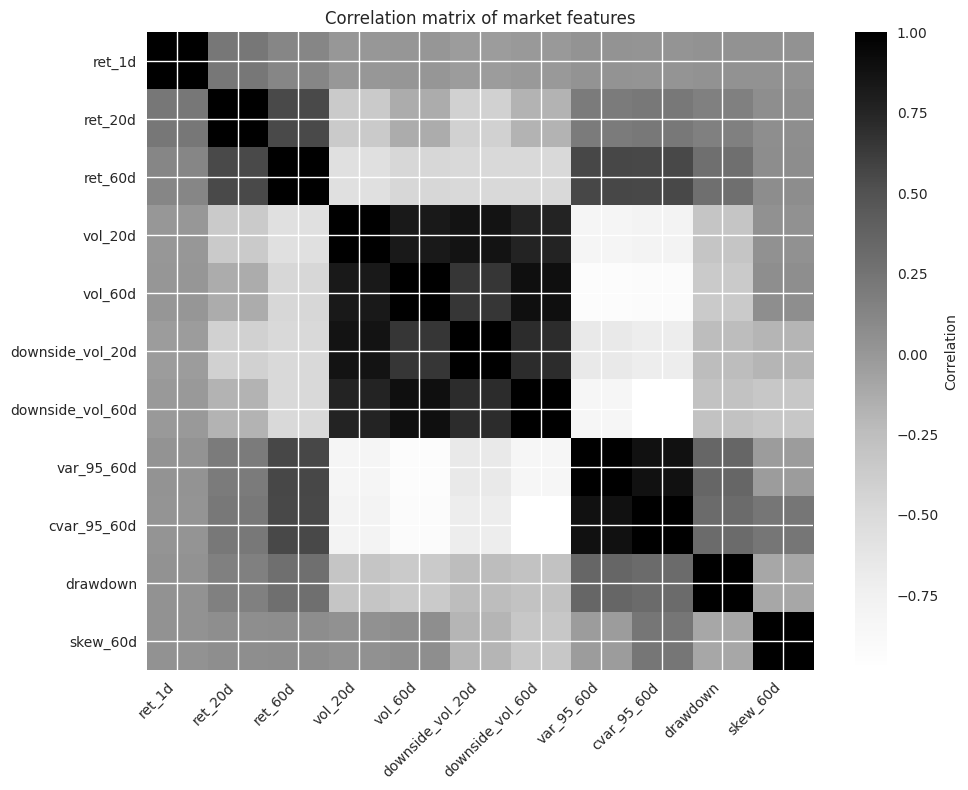

In [128]:
plt.figure(figsize=(10, 8))

im = plt.imshow(corr_matrix, aspect="auto")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

plt.title("Correlation matrix of market features")

cbar = plt.colorbar(im)
cbar.set_label("Correlation")

plt.tight_layout()

# Export figure for Chapter 2
plt.savefig(FIGURES_DIR / "correlation_matrix.png", dpi=300)

plt.show()

### 13. Daily returns

The figure displays the daily log returns of the IBEX 35 over the sample period.

These features provide initial evidence of the relevance of modeling market risk using measures that explicitly account for time variation and extreme events.

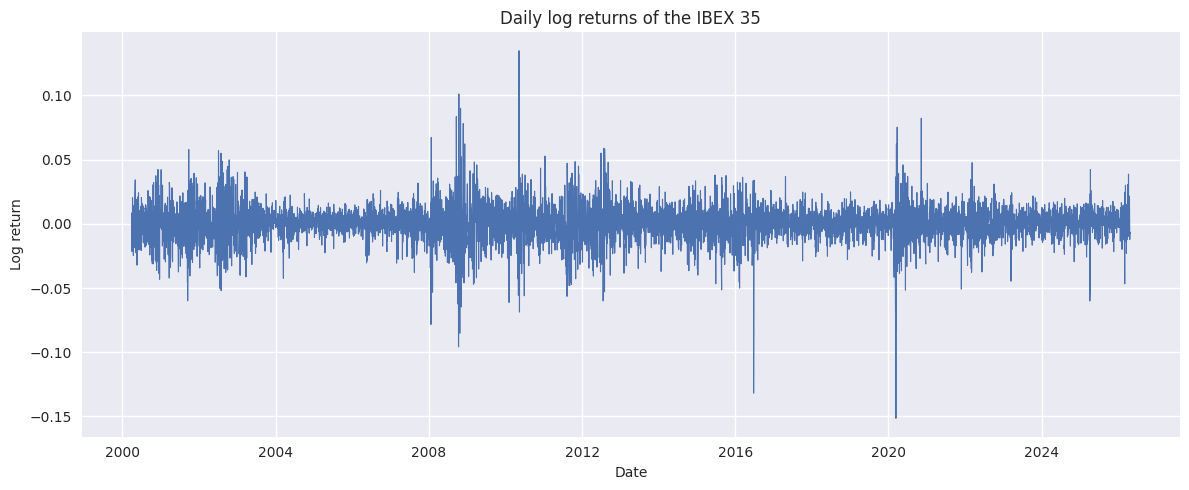

In [129]:
plt.figure(figsize=(12, 5))

plt.plot(master_df["date"], master_df["ret_1d"], linewidth=0.8)

plt.title("Daily log returns of the IBEX 35")
plt.xlabel("Date")
plt.ylabel("Log return")

plt.tight_layout()

# Export figure for Chapter 2
plt.savefig(FIGURES_DIR / "daily_returns_ibex35.png", dpi=300)

plt.show()

### 13.2 Volatility dynamics

The figure shows the evolution of rolling market volatility over a 60-day window.

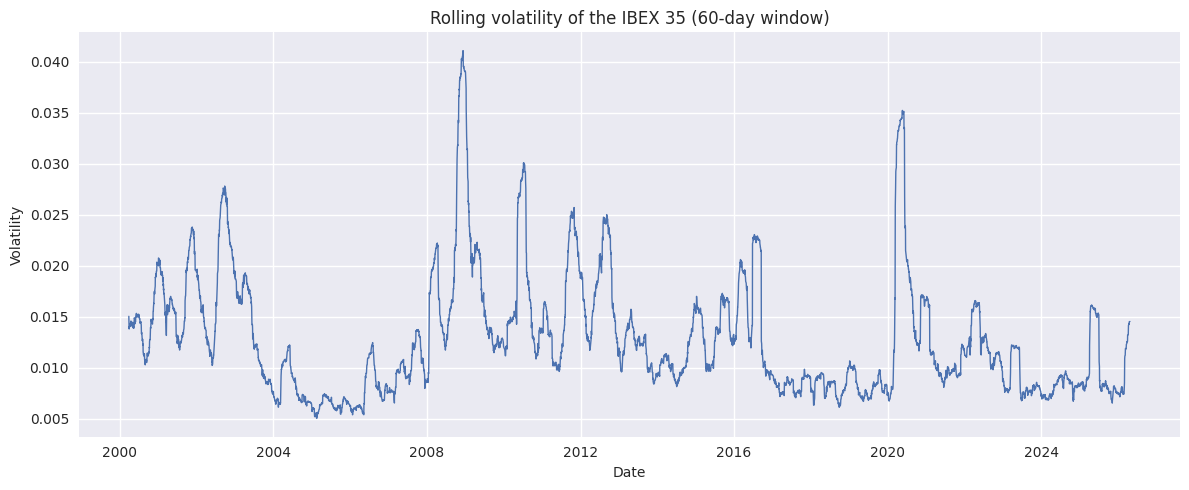

In [130]:
plt.figure(figsize=(12, 5))

plt.plot(master_df["date"], master_df["vol_60d"], linewidth=1)

plt.title("Rolling volatility of the IBEX 35 (60-day window)")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.tight_layout()

# Export figure for Chapter 2
plt.savefig(FIGURES_DIR / "volatility_60d.png", dpi=300)

plt.show()

### 13.3 EWMA volatility

In addition to rolling volatility, an Exponentially Weighted Moving Average (EWMA) measure is introduced. Unlike the rolling standard deviation, EWMA assigns greater weight to more recent observations, allowing it to react more quickly to changes in market conditions.

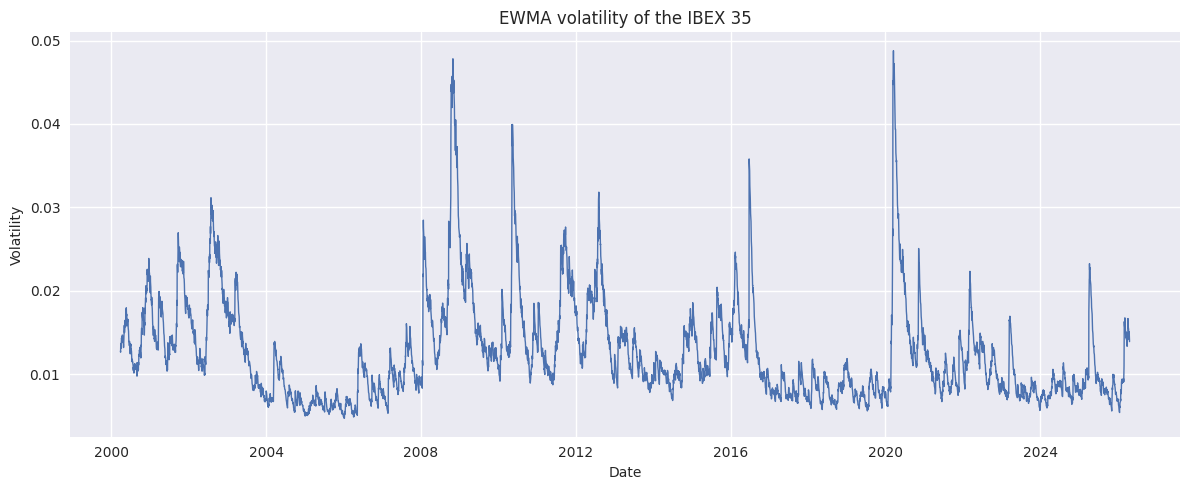

In [140]:
plt.figure(figsize=(12, 5))

plt.plot(master_df["date"], master_df["ewma_vol"], linewidth=1)

plt.title("EWMA volatility of the IBEX 35")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "ewma_volatility.png", dpi=300)

plt.show()

### 13.4 Volatility and downside risk

The figure compares total rolling volatility with downside volatility over a 60-day window.

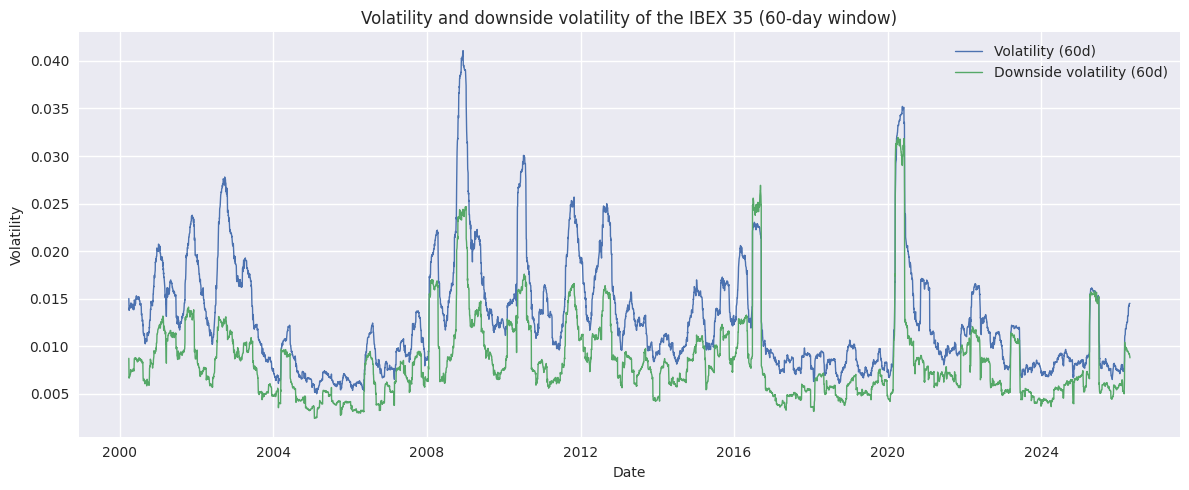

In [132]:
plt.figure(figsize=(12, 5))

plt.plot(master_df["date"], master_df["vol_60d"], label="Volatility (60d)", linewidth=1)
plt.plot(master_df["date"], master_df["downside_vol_60d"], label="Downside volatility (60d)", linewidth=1)

plt.title("Volatility and downside volatility of the IBEX 35 (60-day window)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()

plt.tight_layout()

# Export figure for Chapter 2
plt.savefig(FIGURES_DIR / "volatility_vs_downside_60d.png", dpi=300)

plt.show()

### 13.5 Market drawdown

The figure shows the evolution of market drawdowns over time.

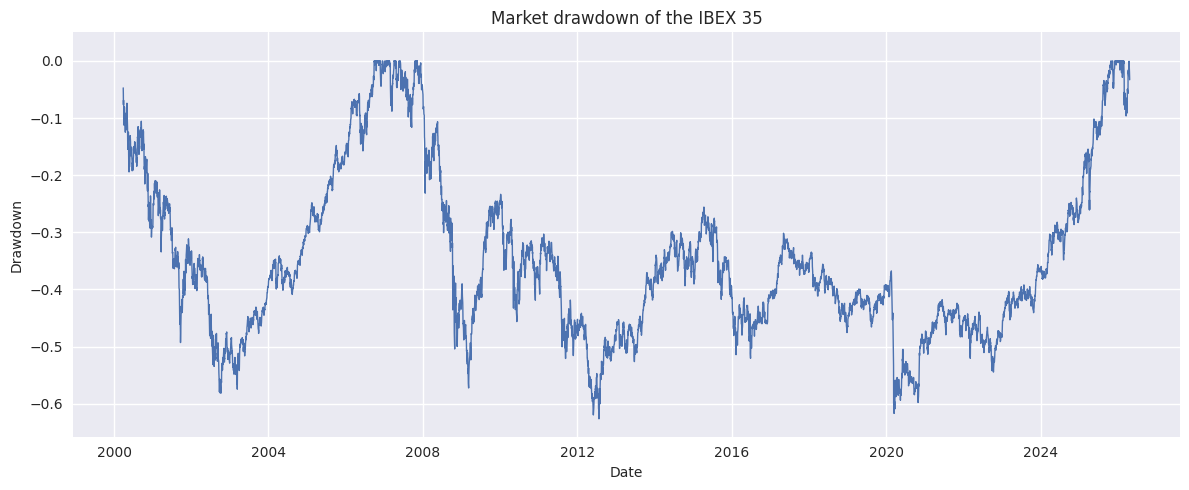

In [133]:
plt.figure(figsize=(12, 5))

plt.plot(master_df["date"], master_df["drawdown"], linewidth=1)

plt.title("Market drawdown of the IBEX 35")
plt.xlabel("Date")
plt.ylabel("Drawdown")

# add upper margin so the series is not stuck to the top boundary
plt.ylim(master_df["drawdown"].min()*1.05, 0.05)

plt.tight_layout()

plt.savefig(FIGURES_DIR / "drawdown_ibex35.png", dpi=300)

plt.show()

### 13.6 Tail risk: VaR and CVaR

The figure presents the evolution of Value at Risk (VaR) and Conditional Value at Risk (CVaR) at the 95% confidence level using a 60-day rolling window.

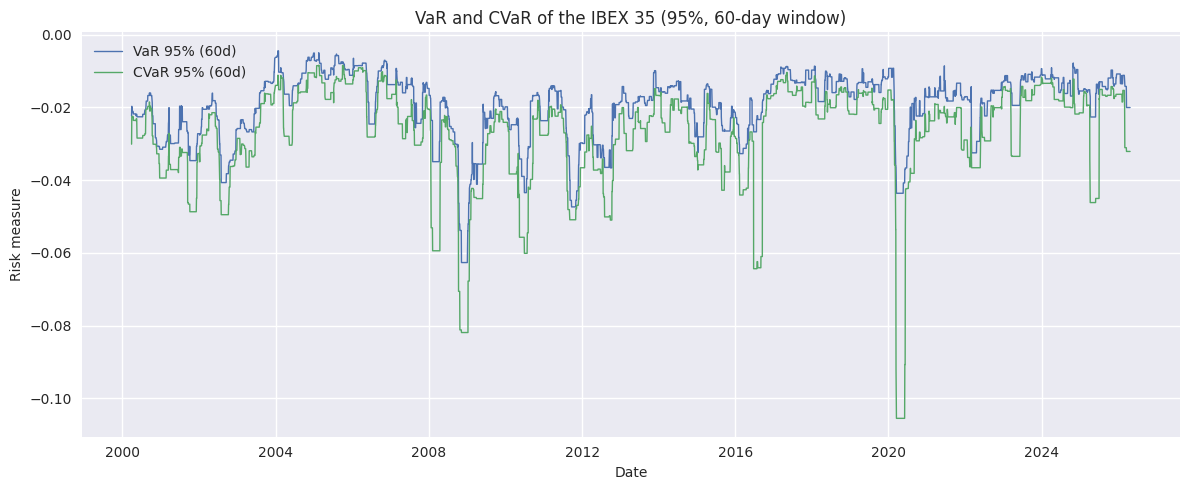

In [134]:
plt.figure(figsize=(12, 5))

plt.plot(master_df["date"], master_df["var_95_60d"], label="VaR 95% (60d)", linewidth=1)
plt.plot(master_df["date"], master_df["cvar_95_60d"], label="CVaR 95% (60d)", linewidth=1)

plt.title("VaR and CVaR of the IBEX 35 (95%, 60-day window)")
plt.xlabel("Date")
plt.ylabel("Risk measure")
plt.legend()

plt.tight_layout()

# Export figure for Chapter 2
plt.savefig(FIGURES_DIR / "var_cvar_60d.png", dpi=300)

plt.show()

### 13.7 Distribution of returns

The figure shows the distribution of daily log returns of the IBEX 35.

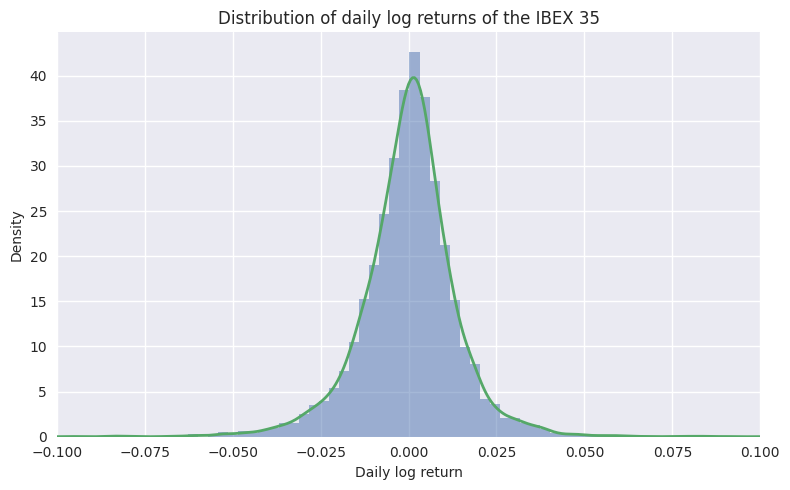

In [135]:
plt.figure(figsize=(8, 5))

# Histograma
plt.hist(master_df["ret_1d"], bins=100, density=True, alpha=0.5)

# KDE
master_df["ret_1d"].plot(kind="kde", linewidth=2)

# Ajuste clave
plt.xlim(-0.1, 0.1)

plt.title("Distribution of daily log returns of the IBEX 35")
plt.xlabel("Daily log return")
plt.ylabel("Density")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "returns_distribution.png", dpi=300)
plt.show()

The distribution of daily returns exhibits clear deviations from normality. In particular, the presence of fat tails and extreme observations highlights the relevance of tail-risk measures such as VaR and CVaR.

This motivates the use of more advanced modelling approaches capable of capturing changes in the underlying market conditions, which are introduced in the following chapter.

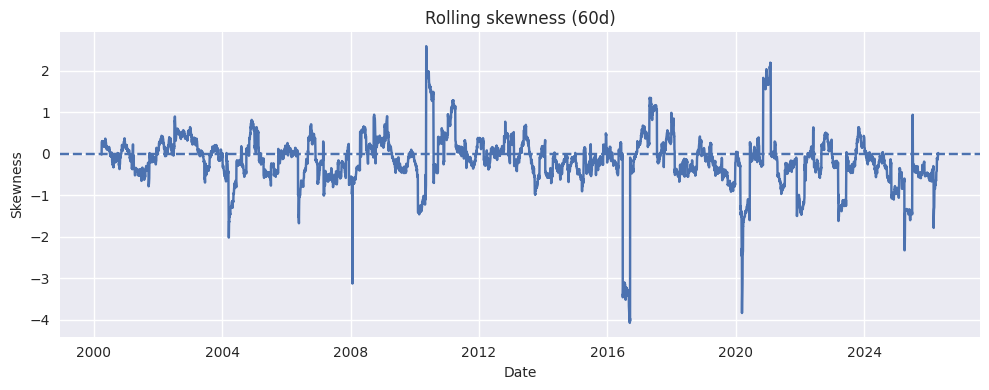

In [136]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar formato datetime
master_df["date"] = pd.to_datetime(master_df["date"])

plt.figure(figsize=(10, 4))

plt.plot(master_df["date"], master_df["skew_60d"])

plt.title("Rolling skewness (60d)")
plt.xlabel("Date")
plt.ylabel("Skewness")

plt.axhline(0, linestyle="--")

plt.tight_layout()

# Guardar figura correctamente en chapter2
plt.savefig(FIGURES_DIR / "skew_60d_series.png", dpi=300)

plt.show()

## Creating risk-adjusted return variables

In this step, we extend the dataset by introducing two new variables that relate return to the level of risk taken over the same rolling horizon.

Specifically, we construct:

- `ret_risk_20d`, defined as the ratio between 20-day cumulative return and 20-day rolling volatility
- `ret_risk_60d`, defined as the ratio between 60-day cumulative return and 60-day rolling volatility

These indicators provide a simple measure of return obtained per unit of risk, allowing us to compare market environments not only in terms of absolute performance, but also in terms of risk-return efficiency.

Before creating them, we have already verified that the required base variables exist in the dataset and do not contain missing values or zero volatility values that could distort the calculation.

In [137]:
import numpy as np

# Create 20-day and 60-day risk-adjusted return variables
# Each variable is computed as cumulative return divided by rolling volatility
master_df["ret_risk_20d"] = master_df["ret_20d"] / master_df["vol_20d"]
master_df["ret_risk_60d"] = master_df["ret_60d"] / master_df["vol_60d"]

# Replace infinite values, if any, with NaN
# This is a safety step in case unexpected numerical issues appear
master_df["ret_risk_20d"] = master_df["ret_risk_20d"].replace([np.inf, -np.inf], np.nan)
master_df["ret_risk_60d"] = master_df["ret_risk_60d"].replace([np.inf, -np.inf], np.nan)

# Check the basic distribution of the newly created variables
print(master_df[["ret_risk_20d", "ret_risk_60d"]].describe())

# Verify whether the new variables contain missing values
print()
print(master_df[["ret_risk_20d", "ret_risk_60d"]].isna().sum())

       ret_risk_20d  ret_risk_60d
count  6,631.000000  6,631.000000
mean       0.832966      1.727179
std        4.585985      7.560197
min      -14.462035    -18.699773
25%       -2.388303     -3.356574
50%        0.581889      1.103165
75%        3.729817      6.358303
max       20.683502     25.653942

ret_risk_20d    0
ret_risk_60d    0
dtype: int64


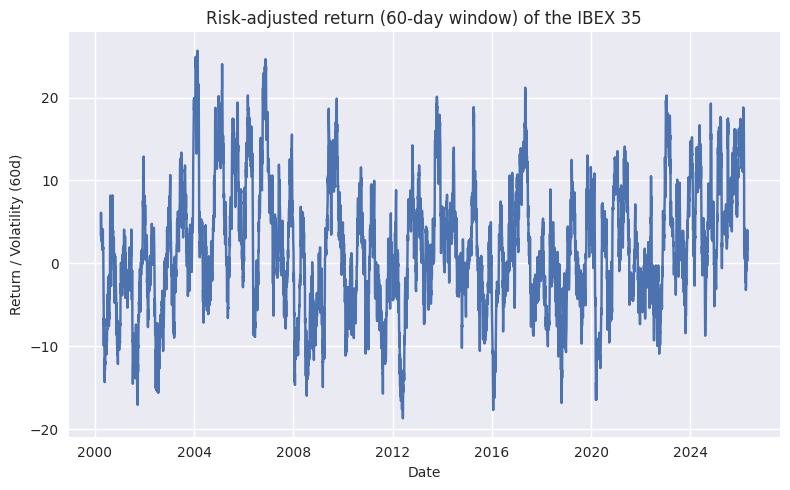

In [138]:
plt.figure(figsize=(8, 5))

plt.plot(master_df["date"], master_df["ret_risk_60d"])

plt.title("Risk-adjusted return (60-day window) of the IBEX 35")
plt.xlabel("Date")
plt.ylabel("Return / Volatility (60d)")

plt.tight_layout()

# Export figure for Chapter 2
plt.savefig(FIGURES_DIR / "ret_risk_60d_series.png", dpi=300)

plt.show()

## Notebook summary

This notebook transformed the cleaned IBEX 35 dataset generated in Notebook 1 into a structured empirical dataset of market features for Chapter 3.

The resulting dataset captures multiple dimensions of market behaviour, including:

- return dynamics
- rolling and EWMA volatility
- downside risk
- tail risk
- cumulative deterioration
- distributional asymmetry
- risk-adjusted performance

These variables provide the empirical basis for the descriptive analysis of market risk developed in Chapter 3 and constitute the input for the following stage of the project.

In [139]:
print("Notebook 02 completed successfully.")
print()
print("Master dataset shape:", master_df.shape)
print("Date coverage:", master_df["date"].min().date(), "to", master_df["date"].max().date())
print()
print("Final columns in master dataset:")
print(list(master_df.columns))
print()
print("Exported files:")
print(" -", PROCESSED_DATA_DIR / "dataset_cap3_master.csv")
print(" -", PROCESSED_DATA_DIR / "dataset_cap4_input.csv")
print(" -", TABLES_DIR / "dataset_summary.csv")
print(" -", TABLES_DIR / "descriptive_statistics.csv")
print(" -", TABLES_DIR / "correlation_matrix.csv")
print(" -", FIGURES_DIR)

Notebook 02 completed successfully.

Master dataset shape: (6631, 18)
Date coverage: 2000-03-28 to 2026-04-23

Final columns in master dataset:
['date', 'ibex_close', 'ret_1d', 'ret_20d', 'ret_60d', 'vol_20d', 'vol_60d', 'ewma_vol', 'downside_vol_20d', 'downside_vol_60d', 'var_95_60d', 'cvar_95_60d', 'drawdown', 'skew_60d', 'sample_split_main', 'sample_split_robust', 'ret_risk_20d', 'ret_risk_60d']

Exported files:
 - /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/data/processed/dataset_cap3_master.csv
 - /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/data/processed/dataset_cap4_input.csv
 - /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/dataset_summary.csv
 - /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/descriptive_statistics.csv
 - /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/correlation_matrix.csv
 - /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/figures/chapter2
